In [23]:
import pandas as pd

In [24]:
from pathlib import Path
import json

ensayos_dir = Path("../ensayos")

rows = []
for txt_file in sorted(ensayos_dir.glob("*.txt")):
    distancia, nombre = txt_file.stem.split("_", 1)
    distancia_m = int(distancia.rstrip("M"))

    with txt_file.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            record = json.loads(line)
            record["archivo"] = txt_file.name
            record["distancia"] = distancia
            record["distancia_m"] = distancia_m
            record["nombre"] = nombre
            rows.append(record)

In [25]:
df_ensayos = pd.DataFrame(rows)

df_ensayos["fecha"] = pd.to_datetime(df_ensayos["fecha"], errors="coerce")

df_ensayos = df_ensayos[
    ["archivo", "distancia", "distancia_m", "nombre", "fecha", "rssi", "mensaje_recibido"]
].sort_values(["distancia_m", "nombre", "fecha"]).reset_index(drop=True)

print(f"Total de registros: {len(df_ensayos)}")

df_ensayos['archivo'] = df_ensayos['archivo'].str.lower()

df_ensayos.head()

Total de registros: 1146


,archivo,distancia,distancia_m,nombre,fecha,rssi,mensaje_recibido
0,5m_antena_chica.txt,5M,5,ANTENA_CHICA,2026-03-05 16:40:08,-76,Envio #0
1,5m_antena_chica.txt,5M,5,ANTENA_CHICA,2026-03-05 16:40:10,-80,Envio #1
2,5m_antena_chica.txt,5M,5,ANTENA_CHICA,2026-03-05 16:40:12,-81,Envio #2
3,5m_antena_chica.txt,5M,5,ANTENA_CHICA,2026-03-05 16:40:14,-86,Envio #3
4,5m_antena_chica.txt,5M,5,ANTENA_CHICA,2026-03-05 16:40:16,-83,Envio #4


In [26]:
# Permite re-ejecutar la celda sin depender de distancia_m
col_distancia = "distancia_m" if "distancia_m" in df_ensayos.columns else "distancia"

df_ensayos = (
    df_ensayos
    .assign(
        distancia=lambda d: pd.to_numeric(d[col_distancia], errors="coerce").astype("Int64"),
        nombre=lambda d: d["nombre"].astype(str).str.replace("_", " ", regex=False).str.lower(),
        mensaje_recibido=lambda d: pd.to_numeric(
            d["mensaje_recibido"].astype(str).str.extract(r"(\d+)", expand=False),
            errors="coerce"
        ).astype("Int64"),
    )
    .drop(columns=["distancia_m"], errors="ignore")
)

df_ensayos.head()

,archivo,distancia,nombre,fecha,rssi,mensaje_recibido
0,5m_antena_chica.txt,5,antena chica,2026-03-05 16:40:08,-76,0
1,5m_antena_chica.txt,5,antena chica,2026-03-05 16:40:10,-80,1
2,5m_antena_chica.txt,5,antena chica,2026-03-05 16:40:12,-81,2
3,5m_antena_chica.txt,5,antena chica,2026-03-05 16:40:14,-86,3
4,5m_antena_chica.txt,5,antena chica,2026-03-05 16:40:16,-83,4


In [27]:
# Orden cronologico por archivo para calcular el tiempo hacia n+1
df_ensayos = df_ensayos.sort_values(["archivo", "fecha"]).reset_index(drop=True)

# Delta en segundos hacia el siguiente registro dentro del mismo archivo
# (sin crear la columna delta_n1)
df_ensayos["delta_n1_seg"] = (
    df_ensayos.groupby("archivo")["fecha"].shift(-1) - df_ensayos["fecha"]
).dt.total_seconds()

print(f"Total de registros: {len(df_ensayos)}")


# Vista final sin las columnas fecha ni delta_n1
df_ensayos[[
    "archivo", "distancia", "nombre", "rssi", "mensaje_recibido", "delta_n1_seg"
]].sample(5)

Total de registros: 1146


,archivo,distancia,nombre,rssi,mensaje_recibido,delta_n1_seg
524,50m_antena_chica.txt,50,antena chica,-86,1690,3.0
355,500m_antena_grande.txt,500,antena grande,-100,1061,2.0
255,100m_antena_grande.txt,100,antena grande,-90,572,2.0
742,5m_antena_chica.txt,5,antena chica,-80,7,3.0
27,100m_antena_chica.txt,100,antena chica,-93,1088,2.0


In [28]:
# Metricas de recepcion por archivo
periodo_envio_obj_seg = 2.0

tasa_recepcion = (
    df_ensayos.groupby("archivo", as_index=False)
    .agg(
        distancia_m=("distancia", "first"),
        tipo_antena=("nombre", "first"),
        mensajes_recibidos=("mensaje_recibido", "count"),
        tiempo_observado_seg=("delta_n1_seg", "sum"),
        intervalo_prom_seg=("delta_n1_seg", "mean"),
        intervalo_mediana_seg=("delta_n1_seg", "median"),
        intervalo_std_seg=("delta_n1_seg", "std"),
        intervalo_p95_seg=("delta_n1_seg", lambda s: s.quantile(0.95)),
        rssi_prom=("rssi", "mean"),
        rssi_min=("rssi", "min"),
        rssi_max=("rssi", "max"),
    )
    .sort_values(["distancia_m", "tipo_antena"])
    .reset_index(drop=True)
)

# Muestras esperadas: se estima por ventana de tiempo observada y periodo objetivo de envio
# Se suma 1 para compensar que hay N-1 intervalos entre N mensajes
tasa_recepcion["mensajes_esperados"] = (
    (tasa_recepcion["tiempo_observado_seg"] / periodo_envio_obj_seg).round().astype("Int64") + 1
)

tasa_recepcion["mensajes_perdidos_est"] = (
    (tasa_recepcion["mensajes_esperados"] - tasa_recepcion["mensajes_recibidos"]) 
    .clip(lower=0)
    .astype("Int64")
)

denom_tiempo = tasa_recepcion["tiempo_observado_seg"].replace(0, pd.NA)

tasa_recepcion["pct_entrega"] = (
    100 * tasa_recepcion["mensajes_recibidos"] / tasa_recepcion["mensajes_esperados"]
).round(2)

tasa_recepcion["tasa_rx_msg_s"] = (
    tasa_recepcion["mensajes_recibidos"] / denom_tiempo
).round(3)

tasa_recepcion["tasa_rx_msg_min"] = (
    60 * tasa_recepcion["mensajes_recibidos"] / denom_tiempo
).round(2)

tasa_recepcion["desfase_intervalo_pct"] = (
    100 * (tasa_recepcion["intervalo_prom_seg"] - periodo_envio_obj_seg) / periodo_envio_obj_seg
).round(2)

tasa_recepcion["periodo_envio_obj_seg"] = periodo_envio_obj_seg

tasa_recepcion

,archivo,distancia_m,tipo_antena,mensajes_recibidos,tiempo_observado_seg,intervalo_prom_seg,intervalo_mediana_seg,intervalo_std_seg,intervalo_p95_seg,rssi_prom,rssi_min,rssi_max,mensajes_esperados,mensajes_perdidos_est,pct_entrega,tasa_rx_msg_s,tasa_rx_msg_min,desfase_intervalo_pct,periodo_envio_obj_seg
0,5m_antena_chica.txt,5,antena chica,166,343.0,2.078788,2.0,0.270228,3.0,-74.897590,-94,-67,173,7,95.95,0.484,29.04,3.94,2.0
1,5m_antena_grande.txt,5,antena grande,116,241.0,2.095652,2.0,0.374023,3.0,-71.215517,-84,-57,121,5,95.87,0.481,28.88,4.78,2.0
2,5m_sin_antena.txt,5,sin antena,129,297.0,2.320312,2.0,2.410390,3.0,-120.046512,-121,-113,149,20,86.58,0.434,26.06,16.02,2.0
3,50m_antena_chica.txt,50,antena chica,176,363.0,2.074286,2.0,0.262988,3.0,-82.278409,-104,-70,183,7,96.17,0.485,29.09,3.71,2.0
4,50m_antena_grande.txt,50,antena grande,185,382.0,2.076087,2.0,0.265861,3.0,-81.172973,-106,-71,192,7,96.35,0.484,29.06,3.80,2.0
5,100m_antena_chica.txt,100,antena chica,160,334.0,2.100629,2.0,0.341163,3.0,-94.968750,-104,-82,168,8,95.24,0.479,28.74,5.03,2.0
6,100m_antena_grande.txt,100,antena grande,157,328.0,2.102564,2.0,0.344158,3.0,-88.936306,-103,-81,165,8,95.15,0.479,28.72,5.13,2.0
7,500m_antena_grande.txt,500,antena grande,57,163.0,2.910714,2.0,2.609610,6.5,-101.350877,-106,-96,83,26,68.67,0.35,20.98,45.54,2.0


In [29]:
# ============================================================
# Configuración global – estilo paper (IEEE / académico)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from scipy import stats

plt.rcParams.update({
    # Fuentes
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "0.6",
    # Líneas y marcadores
    "lines.linewidth": 1.2,
    "lines.markersize": 5,
    # Ejes
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "grid.linewidth": 0.5,
    # Figura
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "figure.figsize": (6, 3.8),
    "figure.constrained_layout.use": True,
})

# Paleta y etiquetas consistentes
ANTENA_ORDER = ["sin antena", "antena chica", "antena grande"]
ANTENA_LABELS = {"sin antena": "Sin antena", "antena chica": "Antena corta", "antena grande": "Antena larga"}
ANTENA_COLORS = {"sin antena": "#1b9e77", "antena chica": "#d95f02", "antena grande": "#7570b3"}
ANTENA_MARKERS = {"sin antena": "s", "antena chica": "^", "antena grande": "o"}
DIST_ORDER = sorted(df_ensayos["distancia"].dropna().unique())

print("Estilo paper configurado ✓")

Estilo paper configurado ✓


## 1. Distribución de RSSI — Boxplot por distancia y tipo de antena

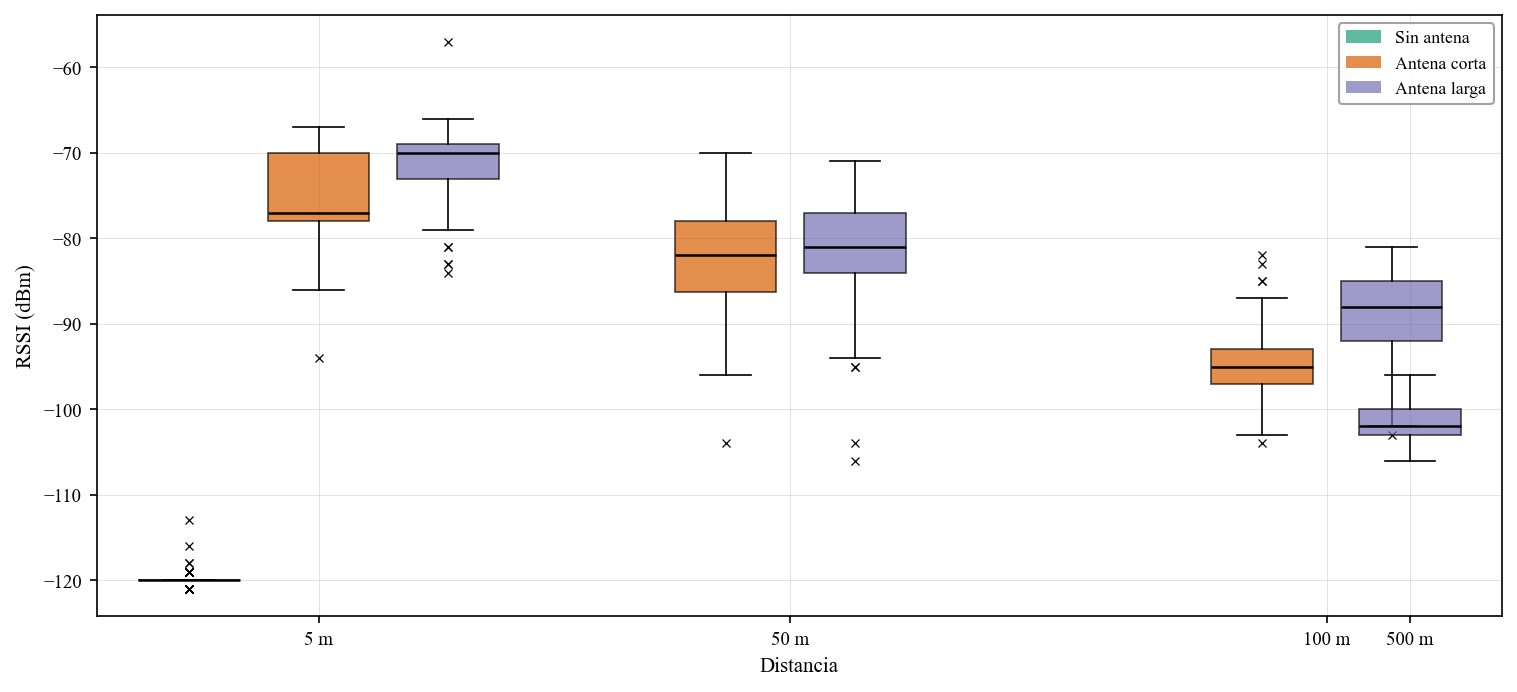

In [30]:
# --- Fig 1: Boxplot RSSI por distancia y tipo de antena ---
fig, ax = plt.subplots(figsize=(10, 4.5))

positions = []
tick_positions = []
tick_labels = []
group_width = 0.7
gap = 1.5
colors_list = []

for i, dist in enumerate(DIST_ORDER):
    antenas_in_dist = df_ensayos[df_ensayos["distancia"] == dist]["nombre"].unique()
    antenas_in_dist = [a for a in ANTENA_ORDER if a in antenas_in_dist]
    n = len(antenas_in_dist)
    center = i * (n * group_width + gap)
    tick_positions.append(center + (n - 1) * group_width / 2)
    tick_labels.append(f"{dist} m")

    for j, ant in enumerate(antenas_in_dist):
        data = df_ensayos[(df_ensayos["distancia"] == dist) & (df_ensayos["nombre"] == ant)]["rssi"]
        pos = center + j * group_width
        bp = ax.boxplot(data, positions=[pos], widths=0.55, patch_artist=True,
                        boxprops=dict(facecolor=ANTENA_COLORS[ant], alpha=0.7, linewidth=0.8),
                        medianprops=dict(color="black", linewidth=1.2),
                        whiskerprops=dict(linewidth=0.8),
                        capprops=dict(linewidth=0.8),
                        flierprops=dict(marker="x", markersize=4, markeredgewidth=0.6))

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_ylabel("RSSI (dBm)")
ax.set_xlabel("Distancia")

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=ANTENA_COLORS[a], alpha=0.7, label=ANTENA_LABELS[a]) for a in ANTENA_ORDER]
ax.legend(handles=legend_elements, loc="upper right")
plt.show()

## 3. RSSI medio vs distancia (con barras de error)

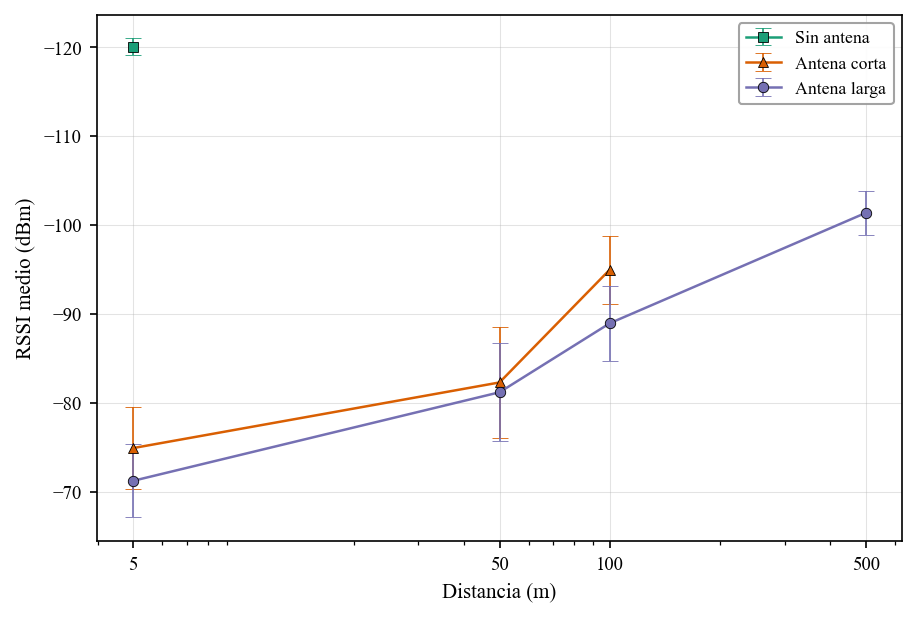

In [31]:
# --- Fig 3: RSSI medio vs distancia con error bars (± 1 σ) ---
fig, ax = plt.subplots(figsize=(6, 4))

for ant in ANTENA_ORDER:
    sub = df_ensayos[df_ensayos["nombre"] == ant]
    if sub.empty:
        continue
    stats_df = sub.groupby("distancia")["rssi"].agg(["mean", "std"]).reindex(DIST_ORDER).dropna()
    ax.errorbar(
        stats_df.index, stats_df["mean"], yerr=stats_df["std"],
        fmt=ANTENA_MARKERS[ant] + "-",
        color=ANTENA_COLORS[ant],
        label=ANTENA_LABELS[ant],
        capsize=4, capthick=0.8, elinewidth=0.8,
        markeredgecolor="black", markeredgewidth=0.4,
    )

ax.set_xscale("log")
ax.set_xticks(DIST_ORDER)
ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel("Distancia (m)")
ax.set_ylabel("RSSI medio (dBm)")
ax.legend()
ax.invert_yaxis()
plt.show()

## 5. Serie temporal de RSSI por ensayo

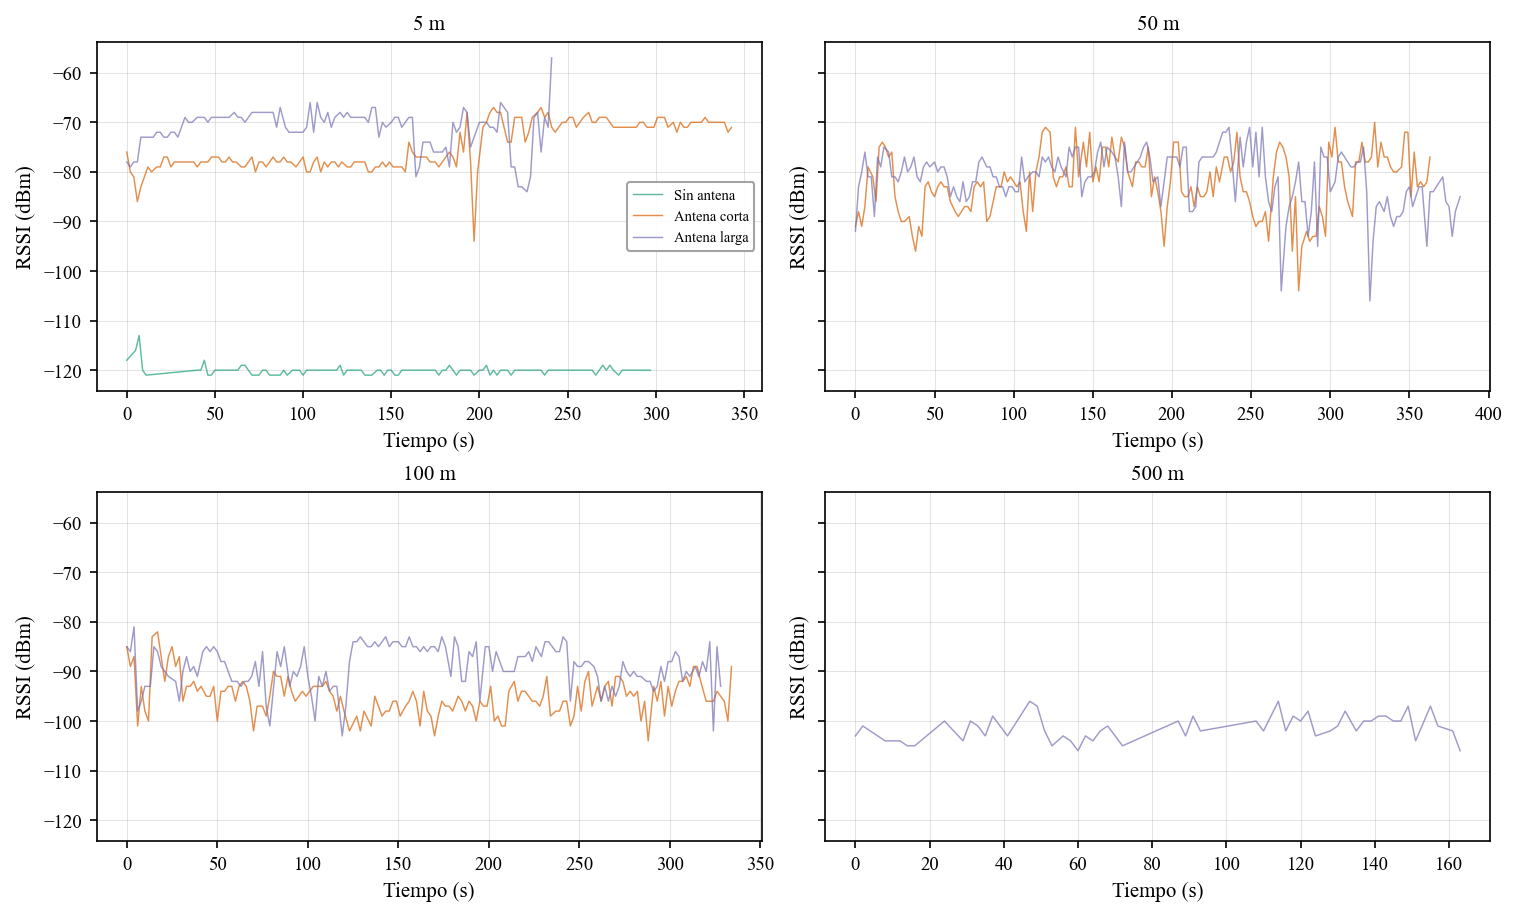

In [32]:
# --- Fig 5: Serie temporal RSSI (un subplot por distancia) ---
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=False, sharey=True)
axes = axes.flatten()

for idx, dist in enumerate(DIST_ORDER):
    ax = axes[idx]
    sub_dist = df_ensayos[df_ensayos["distancia"] == dist]
    for ant in ANTENA_ORDER:
        sub = sub_dist[sub_dist["nombre"] == ant]
        if sub.empty:
            continue
        t = (sub["fecha"] - sub["fecha"].iloc[0]).dt.total_seconds()
        ax.plot(t, sub["rssi"], color=ANTENA_COLORS[ant], alpha=0.7,
                linewidth=0.7, label=ANTENA_LABELS[ant])
    ax.set_title(f"{dist} m", fontsize=10)
    ax.set_ylabel("RSSI (dBm)")
    ax.set_xlabel("Tiempo (s)")
    if idx == 0:
        ax.legend(fontsize=7, loc="center right")

plt.show()

## 9. Tasa de entrega de paquetes (PDR)

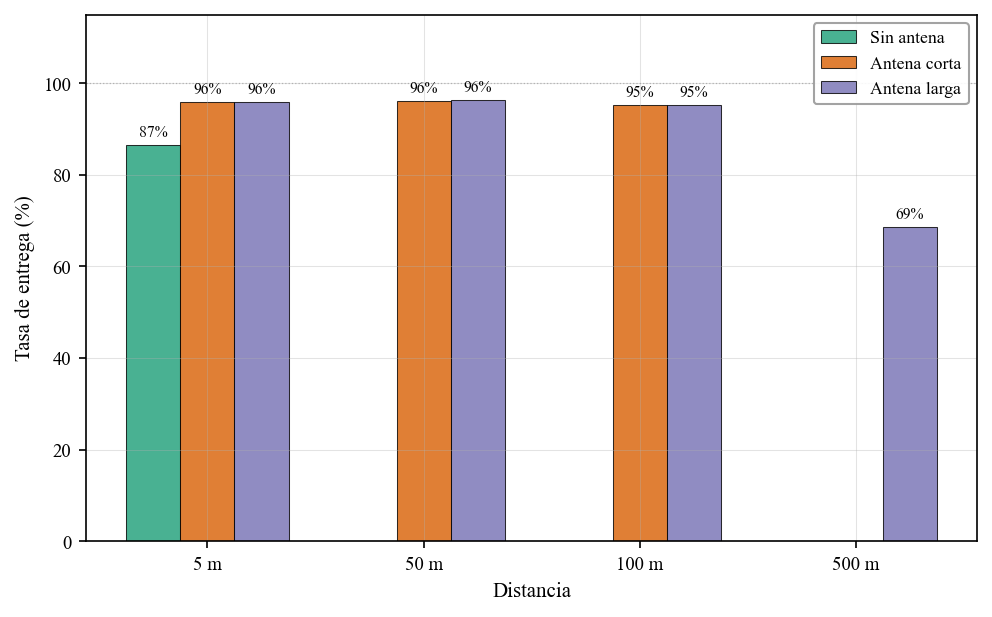

In [33]:
# --- Fig 9: Tasa de entrega (PDR) como barras agrupadas ---
fig, ax = plt.subplots(figsize=(6.5, 4))

bar_width = 0.25
x_pos = np.arange(len(DIST_ORDER))

for i, ant in enumerate(ANTENA_ORDER):
    pdrs = []
    for dist in DIST_ORDER:
        mask = (tasa_recepcion["distancia_m"] == dist) & (tasa_recepcion["tipo_antena"] == ant)
        row = tasa_recepcion[mask]
        if row.empty:
            pdrs.append(0)
        else:
            pdrs.append(row["pct_entrega"].values[0])
    bars = ax.bar(x_pos + i * bar_width, pdrs, bar_width,
                  color=ANTENA_COLORS[ant], edgecolor="black", linewidth=0.5,
                  label=ANTENA_LABELS[ant], alpha=0.8)
    # Anotaciones
    for bar, pdr in zip(bars, pdrs):
        if pdr > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                    f"{pdr:.0f}%", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x_pos + bar_width)
ax.set_xticklabels([f"{d} m" for d in DIST_ORDER])
ax.set_ylabel("Tasa de entrega (%)")
ax.set_xlabel("Distancia")
ax.set_ylim(0, 115)
ax.legend(loc="upper right")
ax.axhline(y=100, color="gray", linestyle=":", linewidth=0.6, alpha=0.5)
plt.show()

## 11. Jitter — Distribución del intervalo entre mensajes

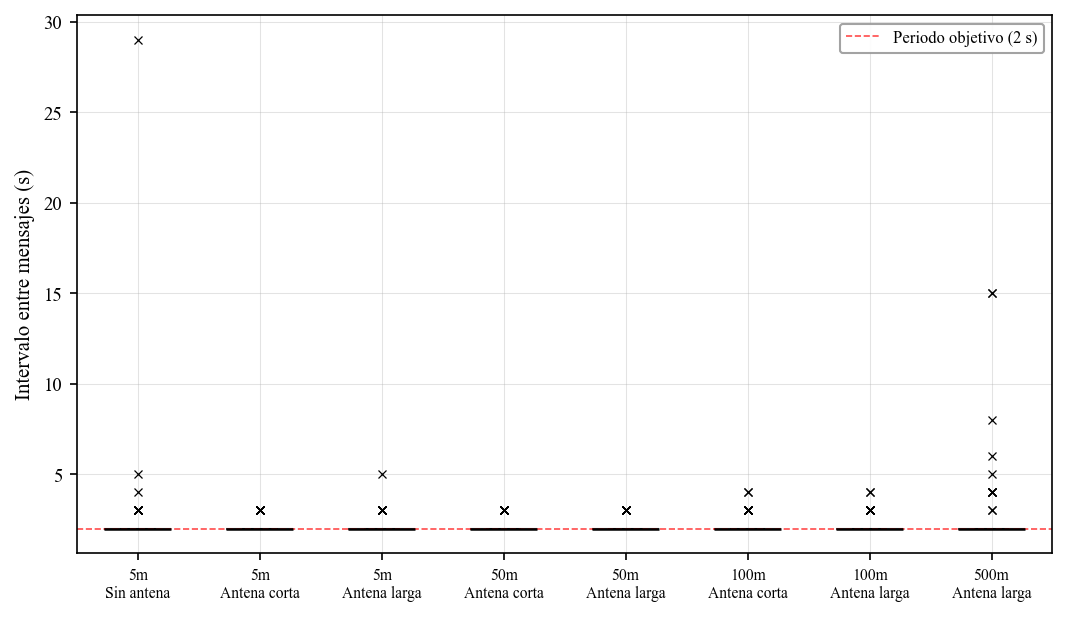

In [34]:
# --- Fig 11: Boxplot del intervalo entre mensajes (jitter) ---
fig, ax = plt.subplots(figsize=(7, 4))

box_data = []
box_labels = []
box_colors = []

for dist in DIST_ORDER:
    for ant in ANTENA_ORDER:
        sub = df_ensayos[(df_ensayos["distancia"] == dist) & (df_ensayos["nombre"] == ant)]
        delta = sub["delta_n1_seg"].dropna()
        if delta.empty:
            continue
        box_data.append(delta.values)
        box_labels.append(f"{dist}m\n{ANTENA_LABELS[ant]}")
        box_colors.append(ANTENA_COLORS[ant])

bp = ax.boxplot(box_data, patch_artist=True, widths=0.55,
                medianprops=dict(color="black", linewidth=1.2),
                whiskerprops=dict(linewidth=0.8),
                capprops=dict(linewidth=0.8),
                flierprops=dict(marker="x", markersize=4, markeredgewidth=0.6))

for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(y=2.0, color="red", linestyle="--", linewidth=0.8, alpha=0.7, label="Periodo objetivo (2 s)")
ax.set_xticklabels(box_labels, fontsize=7.5)
ax.set_ylabel("Intervalo entre mensajes (s)")
ax.legend(loc="upper right", fontsize=8)
plt.show()